# IMPORT LIBRARIES

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(21)


SYNTHETIC DATASET GENERATION
10000 samples
800 features
10 classes

In [ ]:
num_samples = 10000
img_height = 30
img_width = 60
num_features = img_height * img_width # 30 x 60 = 1800 features

num_classes = 10

# Random grayscale values (0-255)

In [3]:
X = np.random.randint(0, 256, size=(num_samples, num_features))

# Normalize to 0-1

In [4]:
X = X / 255.0

# Random labels

In [25]:
y = np.random.randint(0, num_classes, size=(num_samples,))

print("Input Shape :", X.shape)

Input Shape : (10000, 1800)


# DISPLAY SAMPLE PSEUDO IMAGE

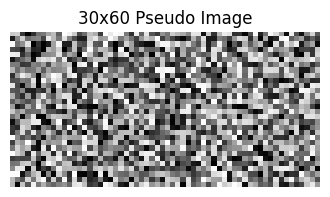

In [24]:
plt.figure(figsize=(4, 3))

sample_image = X[0].reshape(img_height, img_width)

plt.imshow(sample_image, cmap='gray')

plt.title("30x60 Pseudo Image")

plt.axis('off')

plt.show()

# ONE HOT ENCODING

In [6]:
def one_hot_encode(y, num_classes):

    one_hot = np.zeros((len(y), num_classes))

    for i in range(len(y)):
        one_hot[i, y[i]] = 1

    return one_hot

y_encoded = one_hot_encode(y, num_classes)

# TRAIN TEST SPLIT

In [7]:
def train_test_split(X, y, test_size=0.2):

    num_samples = X.shape[0]

    indices = np.arange(num_samples)

    np.random.shuffle(indices)

    split_index = int(num_samples * (1 - test_size))

    train_indices = indices[:split_index]
    test_indices = indices[split_index:]

    X_train = X[train_indices]
    X_test = X[test_indices]

    y_train = y[train_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (8000, 1800)
Testing Shape  : (2000, 1800)


# ACTIVATION FUNCTIONS

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)


def tanh(z):
    return np.tanh(z)

def tanh_derivative(a):
    return 1 - np.square(a)


def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)


def softmax(z):

    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))

    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# LOSS FUNCTION

In [9]:
def cross_entropy_loss(y_true, y_pred):

    epsilon = 1e-10

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    return loss

# ACCURACY FUNCTION

In [10]:
def compute_accuracy(y_true, y_pred):

    y_true_labels = np.argmax(y_true, axis=1)

    y_pred_labels = np.argmax(y_pred, axis=1)

    accuracy = np.mean(y_true_labels == y_pred_labels)

    return accuracy

# NEURAL NETWORK CLASS

In [11]:
class NeuralNetwork:

    def __init__(
        self,
        input_size,
        hidden1,
        hidden2,
        hidden3,
        output_size,
        activation='relu',
        learning_rate=0.01
    ):

        self.lr = learning_rate
        self.activation_name = activation

        # ====================================================
        # WEIGHT INITIALIZATION
        # ====================================================

        self.W1 = np.random.randn(input_size, hidden1) * 0.01
        self.b1 = np.zeros((1, hidden1))

        self.W2 = np.random.randn(hidden1, hidden2) * 0.01
        self.b2 = np.zeros((1, hidden2))

        self.W3 = np.random.randn(hidden2, hidden3) * 0.01
        self.b3 = np.zeros((1, hidden3))

        self.W4 = np.random.randn(hidden3, output_size) * 0.01
        self.b4 = np.zeros((1, output_size))

    # ========================================================
    # ACTIVATION SELECTOR
    # ========================================================

    def activation(self, z):

        if self.activation_name == 'sigmoid':
            return sigmoid(z)

        elif self.activation_name == 'tanh':
            return tanh(z)

        else:
            return relu(z)

    # --------------------------------------------------------

    def activation_derivative(self, a, z):

        if self.activation_name == 'sigmoid':
            return sigmoid_derivative(a)

        elif self.activation_name == 'tanh':
            return tanh_derivative(a)

        else:
            return relu_derivative(z)

    # ========================================================
    # FORWARD PROPAGATION
    # ========================================================

    def forward(self, X):

        # Layer 1
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.activation(self.Z1)

        # Layer 2
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.activation(self.Z2)

        # Layer 3
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = self.activation(self.Z3)

        # Output Layer
        self.Z4 = np.dot(self.A3, self.W4) + self.b4
        self.A4 = softmax(self.Z4)

        return self.A4

    # ========================================================
    # BACKPROPAGATION
    # ========================================================

    def backward(self, X, y):

        m = X.shape[0]

        # ====================================================
        # OUTPUT LAYER
        # ====================================================

        dZ4 = self.A4 - y

        dW4 = np.dot(self.A3.T, dZ4) / m
        db4 = np.sum(dZ4, axis=0, keepdims=True) / m

        # ====================================================
        # HIDDEN LAYER 3
        # ====================================================

        dA3 = np.dot(dZ4, self.W4.T)

        dZ3 = dA3 * self.activation_derivative(
            self.A3,
            self.Z3
        )

        dW3 = np.dot(self.A2.T, dZ3) / m
        db3 = np.sum(dZ3, axis=0, keepdims=True) / m

        # ====================================================
        # HIDDEN LAYER 2
        # ====================================================

        dA2 = np.dot(dZ3, self.W3.T)

        dZ2 = dA2 * self.activation_derivative(
            self.A2,
            self.Z2
        )

        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # ====================================================
        # HIDDEN LAYER 1
        # ====================================================

        dA1 = np.dot(dZ2, self.W2.T)

        dZ1 = dA1 * self.activation_derivative(
            self.A1,
            self.Z1
        )

        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # ====================================================
        # GRADIENT DESCENT UPDATE
        # ====================================================

        self.W4 -= self.lr * dW4
        self.b4 -= self.lr * db4

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    # ========================================================
    # TRAINING FUNCTION
    # ========================================================

    def train(self, X, y, epochs=100):

        losses = []
        accuracies = []

        for epoch in range(epochs):

            predictions = self.forward(X)

            loss = cross_entropy_loss(y, predictions)

            accuracy = compute_accuracy(y, predictions)

            self.backward(X, y)

            losses.append(loss)
            accuracies.append(accuracy)

            if epoch % 10 == 0:

                print(
                    f"Epoch {epoch} | "
                    f"Loss = {loss:.4f} | "
                    f"Accuracy = {accuracy:.4f}"
                )

        return losses, accuracies


DIFFERENT HIDDEN LAYER CONFIGURATIONS

In [12]:
hidden_layer_configs = [

    (64, 32, 16),

    (128, 64, 32),

    (256, 128, 64)

]

ACTIVATION FUNCTIONS

In [13]:
activation_functions = [

    'relu',

    'sigmoid',

    'tanh'

]

# TRAIN MODELS

In [15]:
results = {}

for activation in activation_functions:

    for config in hidden_layer_configs:

        print("\n========================================")
        print(f"Activation Function : {activation}")
        print(f"Hidden Layers       : {config}")
        print("========================================")

        model = NeuralNetwork(

            input_size=1800,

            hidden1=config[0],

            hidden2=config[1],

            hidden3=config[2],

            output_size=10,

            activation=activation,

            learning_rate=0.01
        )

        losses, accuracies = model.train(

            X_train,

            y_train,

            epochs=50
        )

        key = f"{activation}_{config}"

        results[key] = {

            'losses': losses,

            'accuracies': accuracies
        }


Activation Function : relu
Hidden Layers       : (64, 32, 16)
Epoch 0 | Loss = 2.3026 | Accuracy = 0.0988
Epoch 10 | Loss = 2.3026 | Accuracy = 0.1082
Epoch 20 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 30 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 40 | Loss = 2.3025 | Accuracy = 0.1082

Activation Function : relu
Hidden Layers       : (128, 64, 32)
Epoch 0 | Loss = 2.3026 | Accuracy = 0.0985
Epoch 10 | Loss = 2.3026 | Accuracy = 0.1082
Epoch 20 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 30 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 40 | Loss = 2.3025 | Accuracy = 0.1082

Activation Function : relu
Hidden Layers       : (256, 128, 64)
Epoch 0 | Loss = 2.3026 | Accuracy = 0.1006
Epoch 10 | Loss = 2.3026 | Accuracy = 0.1082
Epoch 20 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 30 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 40 | Loss = 2.3025 | Accuracy = 0.1082

Activation Function : sigmoid
Hidden Layers       : (64, 32, 16)
Epoch 0 | Loss = 2.3030 | Accuracy = 0.0969
Epoch 10 | Loss = 2.3029 |

# PLOT LOSS CURVES

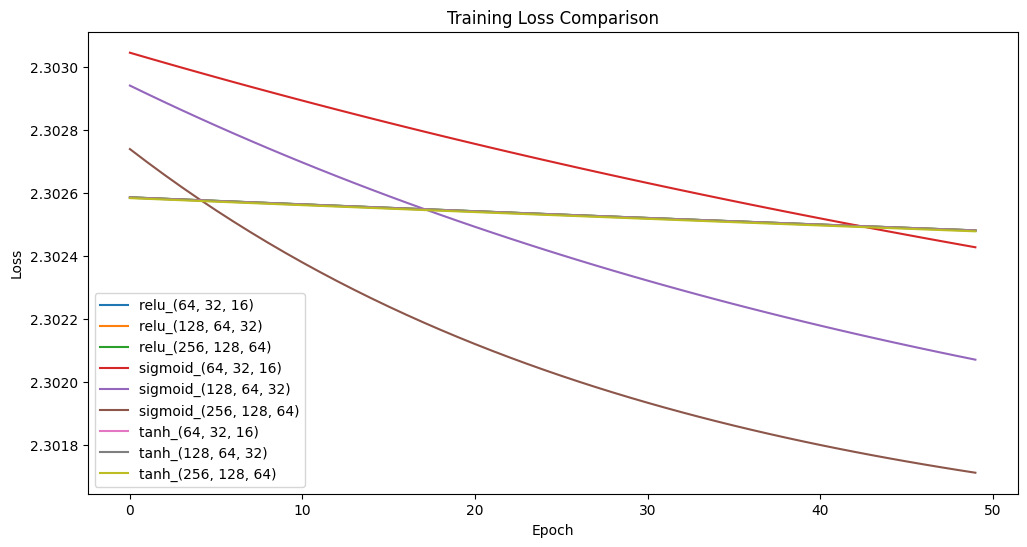

In [16]:
plt.figure(figsize=(12, 6))

for key in results:

    plt.plot(results[key]['losses'], label=key)

plt.title("Training Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()


# PLOT ACCURACY CURVES

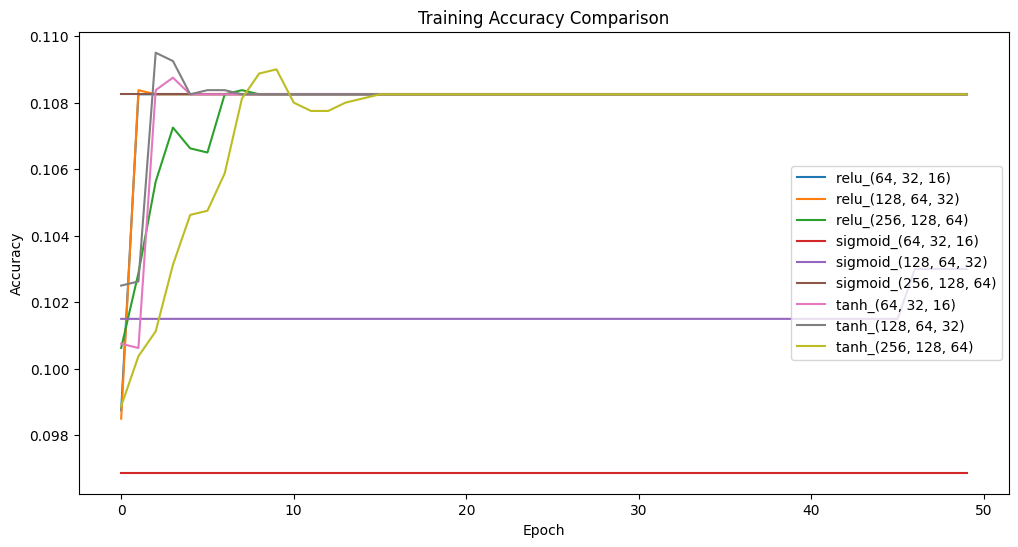

In [17]:
plt.figure(figsize=(12, 6))

for key in results:

    plt.plot(results[key]['accuracies'], label=key)

plt.title("Training Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# LEARNING RATE EXPERIMENT


Training with Learning Rate = 0.001
Epoch 0 | Loss = 2.3026 | Accuracy = 0.1009
Epoch 10 | Loss = 2.3026 | Accuracy = 0.1025
Epoch 20 | Loss = 2.3026 | Accuracy = 0.1072
Epoch 30 | Loss = 2.3026 | Accuracy = 0.1081
Epoch 40 | Loss = 2.3026 | Accuracy = 0.1082

Training with Learning Rate = 0.01
Epoch 0 | Loss = 2.3026 | Accuracy = 0.0980
Epoch 10 | Loss = 2.3026 | Accuracy = 0.1082
Epoch 20 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 30 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 40 | Loss = 2.3025 | Accuracy = 0.1082

Training with Learning Rate = 0.05
Epoch 0 | Loss = 2.3026 | Accuracy = 0.1003
Epoch 10 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 20 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 30 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 40 | Loss = 2.3022 | Accuracy = 0.1082

Training with Learning Rate = 0.1
Epoch 0 | Loss = 2.3026 | Accuracy = 0.1103
Epoch 10 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 20 | Loss = 2.3022 | Accuracy = 0.1082
Epoch 30 | Loss = 2.3021 | Accuracy = 0.1082
Epoch

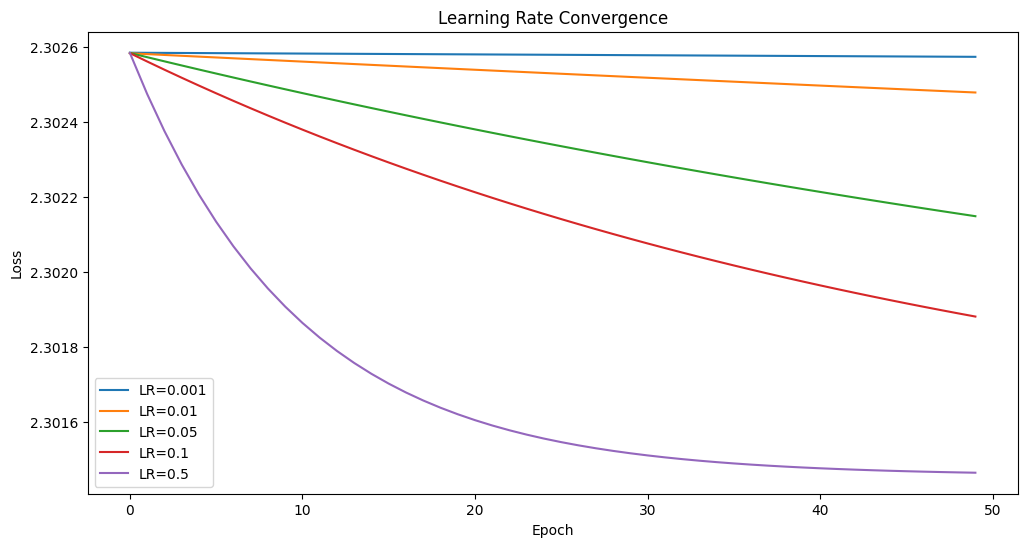

In [19]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]

plt.figure(figsize=(12, 6))

for lr in learning_rates:

    print(f"\nTraining with Learning Rate = {lr}")

    model = NeuralNetwork(

        input_size=1800,

        hidden1=128,

        hidden2=64,

        hidden3=32,

        output_size=10,

        activation='relu',

        learning_rate=lr
    )

    losses, _ = model.train(

        X_train,

        y_train,

        epochs=50
    )

    plt.plot(losses, label=f"LR={lr}")

plt.title("Learning Rate Convergence")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

# EPOCH EXPERIMENT


Training for 50 epochs
Epoch 0 | Loss = 2.3026 | Accuracy = 0.0994
Epoch 10 | Loss = 2.3026 | Accuracy = 0.1082
Epoch 20 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 30 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 40 | Loss = 2.3025 | Accuracy = 0.1082


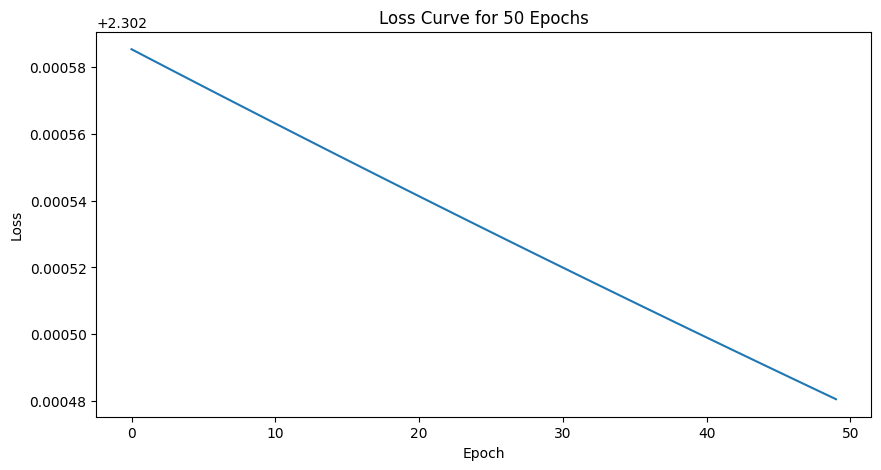


Training for 100 epochs
Epoch 0 | Loss = 2.3026 | Accuracy = 0.1025
Epoch 10 | Loss = 2.3026 | Accuracy = 0.1082
Epoch 20 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 30 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 40 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 50 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 60 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 70 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 80 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 90 | Loss = 2.3024 | Accuracy = 0.1082


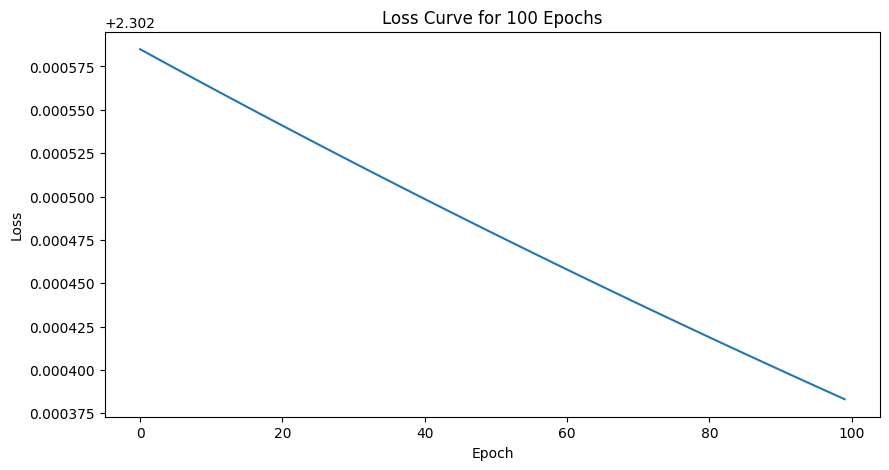


Training for 200 epochs
Epoch 0 | Loss = 2.3026 | Accuracy = 0.1020
Epoch 10 | Loss = 2.3026 | Accuracy = 0.1082
Epoch 20 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 30 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 40 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 50 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 60 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 70 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 80 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 90 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 100 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 110 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 120 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 130 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 140 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 150 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 160 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 170 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 180 | Loss = 2.3022 | Accuracy = 0.1082
Epoch 190 | Loss = 2.3022 | Accuracy = 0.1082


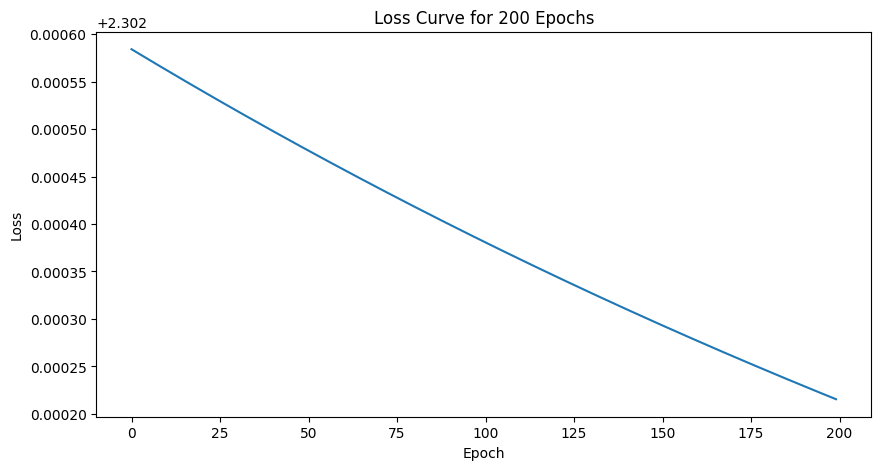


Training for 500 epochs
Epoch 0 | Loss = 2.3026 | Accuracy = 0.0993
Epoch 10 | Loss = 2.3026 | Accuracy = 0.1082
Epoch 20 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 30 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 40 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 50 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 60 | Loss = 2.3025 | Accuracy = 0.1082
Epoch 70 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 80 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 90 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 100 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 110 | Loss = 2.3024 | Accuracy = 0.1082
Epoch 120 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 130 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 140 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 150 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 160 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 170 | Loss = 2.3023 | Accuracy = 0.1082
Epoch 180 | Loss = 2.3022 | Accuracy = 0.1082
Epoch 190 | Loss = 2.3022 | Accuracy = 0.1082
Epoch 200 | Loss = 2.3022 | Accuracy = 0.1082
Epoch 210 | Loss = 2

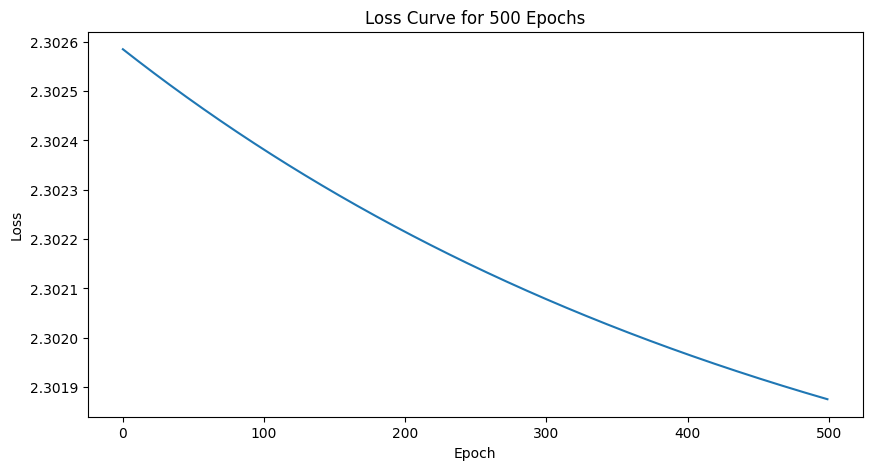

In [21]:
epoch_values = [50, 100, 200, 500]

for ep in epoch_values:

    print("\n================================")
    print(f"Training for {ep} epochs")
    print("================================")

    model = NeuralNetwork(

        input_size=1800,

        hidden1=128,

        hidden2=64,

        hidden3=32,

        output_size=10,

        activation='relu',

        learning_rate=0.01
    )

    losses, accuracies = model.train(

        X_train,

        y_train,

        epochs=ep
    )

    plt.figure(figsize=(10, 5))

    plt.plot(losses)

    plt.title(f"Loss Curve for {ep} Epochs")

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.show()

# FINAL TEST ACCURACY

In [22]:
final_predictions = model.forward(X_test)

test_accuracy = compute_accuracy(
    y_test,
    final_predictions
)

print("\nFinal Test Accuracy :", test_accuracy)


Final Test Accuracy : 0.095
